# Lab Instructions

You are part of a data team for a financial institution that uses an AI model to determine who will and will not be granted a loan.  Recently, there have been complaints from customers that the model unfairly discriminates based on the applicant's age and sex. A court has ordered that the financial institution must provide information about how the model works.  

Data from recent loan applications is given in `loan_data.csv`.  The data dictionary is below:

| Feature              | Description | Data Type |
| :---------------- | :------: | ----: |
|person_age|Age of the person|Float
|person_gender|Gender of the person|Categorical
|person_education|Highest education level|Categorical
|person_income|Annual income|Float
|person_emp_exp|Years of employment experience|Integer
|person_home_ownership|Home ownership status (e.g., rent, own, mortgage)|Categorical
|loan_amnt|Loan amount requested|Float
|loan_intent|Purpose of the loan|Categorical
|loan_int_rate|Loan interest rate|Float
|loan_percent_income|Loan amount as a percentage of annual income|Float
|cb_person_cred_hist_length|Length of credit history in years|Float
|credit_score|Credit score of the person|Integer
|previous_loan_defaults_on_file|Indicator of previous loan defaults|Categorical
|loan_status (target variable)|Loan approval status: 1 = approved; 0 = rejected|Integer

Visualize the relationship between age, sex and 5 other features with `loan_status`.  Which features seem to drive the model's decision to grant a loan?  Which seem unrelated?  Should the financial institution be concerned about potential legal trouble?  Make sure to justify your answers with specific references to your visualizations.

**You must use quantitative visualizations (boxplots or histograms) when comparing quantitative features.  DO NOT categorize quantitative features.**

I do not see any harmful corelation between gender and unfair denials.
Viewing the data we see that the gender approval and rejection rating match, showing a higher rate in both for men, mostly because it seems that more men filed for loans.

Viewing the data for age however, we see that there are zero loan approvals for anyone over 60 years old, which could indicate a trend of discrimination since the number of applicants shows no major change.

Otherwise, we see positive trends for applicants with a credit score of over 700, applicants with over 10 years of credit history, and anyone applying for the minimum loan ammount. This makes sense, because these either show that you have a positive history of payments, or are applying for a loan that is a lower risk of loss to the bank.

The denial rate increases for anyone that makes less than a $60,000 salary, which also could make sense if denial is taking income into account agains loan amount while deciding loan approvals.


There is a potential for legal trouble from age discrimination accusations, however it is normal to deny loans to people who could potentially not pay the loan back for any reason, and it is reasonable for the institution to deny these loans if they have a genuine risk of loss of the applicant passing away before the loan has been fully paid.

<Axes: ylabel='Frequency'>

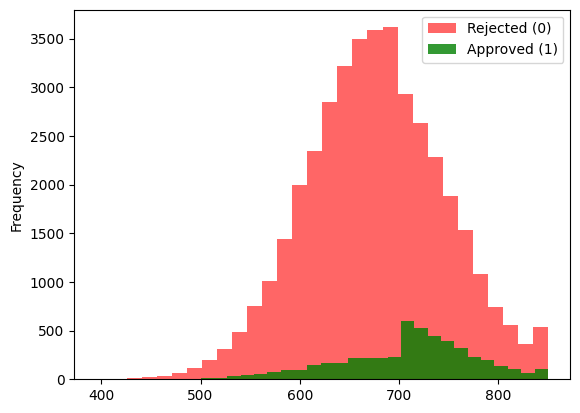

In [90]:
import pandas as pd
# load data
df = pd.read_csv("loan_data.csv")

# features: age, sex, and five quantitative features
num_features = [
    "person_age",
    "person_income",
    "loan_amnt",
    "loan_int_rate",
    "credit_score",
    "cb_person_cred_hist_length",
]

#Based on credit score. There is a sharp increase in approval above 700 credit score.
df[df["loan_status"] == 0]["credit_score"].plot.hist(bins=30, alpha=0.6, label="Rejected (0)", color='red', legend=True)
df[df["loan_status"] == 1]["credit_score"].plot.hist(bins=30, alpha=0.8, label="Approved (1)", color='green', legend=True)

<Axes: ylabel='Frequency'>

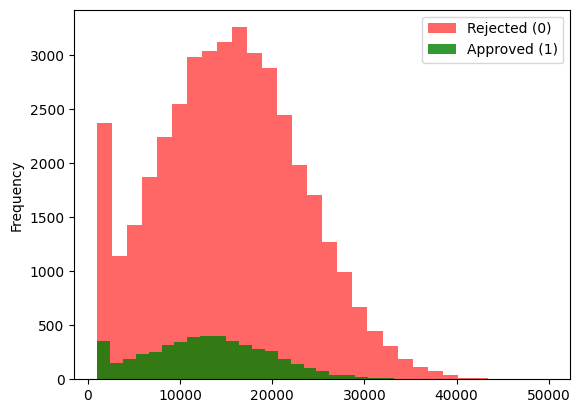

In [91]:
df[df["loan_status"] == 0]["loan_amnt"].plot.hist(bins=30, alpha=0.6, label="Rejected (0)", color='red', legend=True)
df[df["loan_status"] == 1]["loan_amnt"].plot.hist(bins=30, alpha=0.8, label="Approved (1)", color='green', legend=True)

<Axes: ylabel='Frequency'>

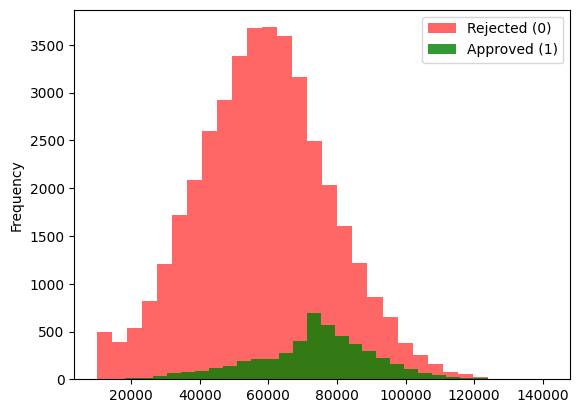

In [92]:
df[df["loan_status"] == 0]["person_income"].plot.hist(bins=30, alpha=0.6, label="Rejected (0)", color='red', legend=True)
df[df["loan_status"] == 1]["person_income"].plot.hist(bins=30, alpha=0.8, label="Approved (1)", color='green', legend=True)

<Axes: ylabel='Frequency'>

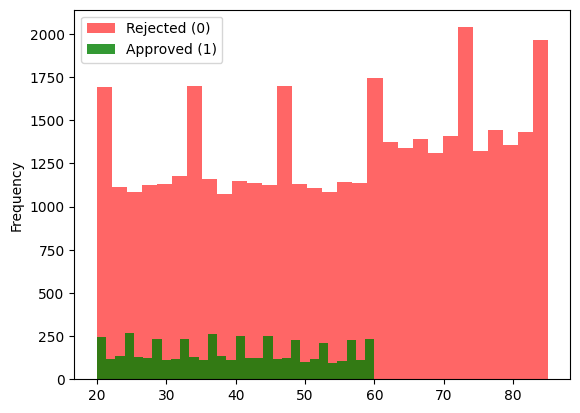

In [93]:
#No approvals over 60 years old
df[df["loan_status"] == 0]["person_age"].plot.hist(bins=30, alpha=0.6, label="Rejected (0)", color='red', legend=True)
df[df["loan_status"] == 1]["person_age"].plot.hist(bins=30, alpha=0.8, label="Approved (1)", color='green', legend=True)

<Axes: ylabel='Frequency'>

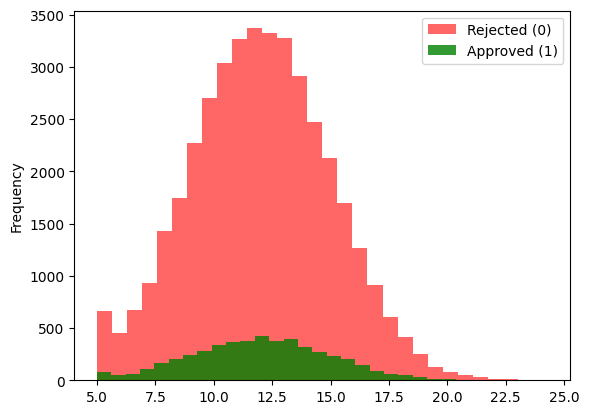

In [94]:
#Nothing abnormal in dist of interest rate besides a small bump at 5%
df[df["loan_status"] == 0]["loan_int_rate"].plot.hist(bins=30, alpha=0.6, label="Rejected (0)", color='red', legend=True)
df[df["loan_status"] == 1]["loan_int_rate"].plot.hist(bins=30, alpha=0.8, label="Approved (1)", color='green', legend=True)

<Axes: ylabel='Frequency'>

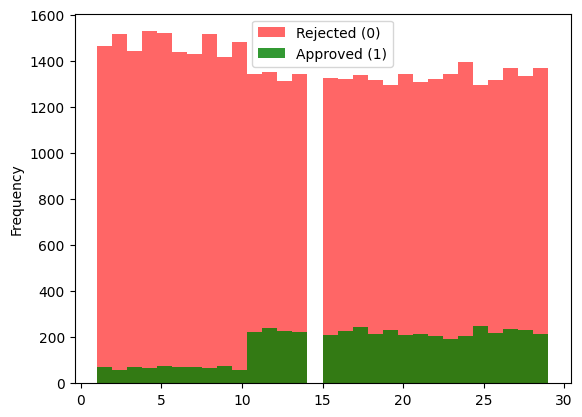

In [95]:
#Weird missing data at 14 years, otherwise a sharp jump after 10 years of credit history.
df[df["loan_status"] == 0]["cb_person_cred_hist_length"].plot.hist(bins=30, alpha=0.6, label="Rejected (0)", color='red', legend=True)
df[df["loan_status"] == 1]["cb_person_cred_hist_length"].plot.hist(bins=30, alpha=0.8, label="Approved (1)", color='green', legend=True)

<Axes: title={'center': 'Rejected (0)'}>

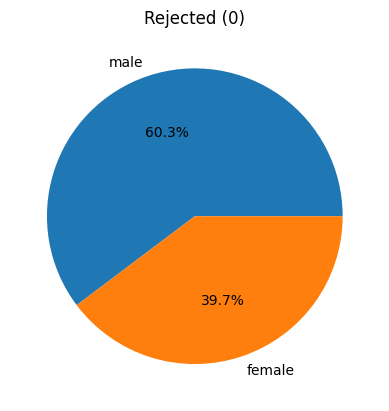

In [96]:
df[df["loan_status"] == 0]["person_gender"].value_counts().plot.pie(autopct="%1.1f%%", title="Rejected (0)")

<Axes: title={'center': 'Approved (1)'}>

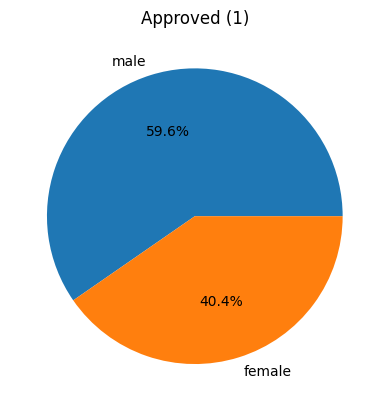

In [97]:
df[df["loan_status"] == 1]["person_gender"].value_counts().plot.pie(autopct="%1.1f%%", title="Approved (1)")

<Axes: title={'center': 'Rejected (0)'}>

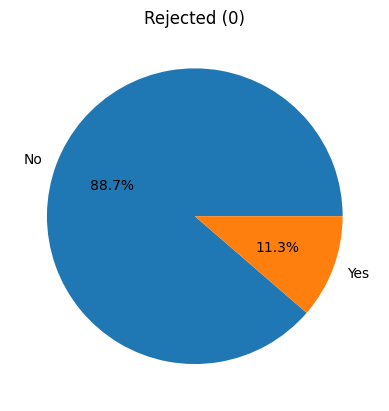

In [98]:
df[df["loan_status"] == 0]["previous_loan_defaults_on_file"].value_counts().plot.pie(autopct="%1.1f%%", title="Rejected (0)")